<h1>Caso de uso: Covid<h1>

In [4]:
import pandas as pd

In [9]:
df_covid = pd.read_csv(r'C:\Users\lozan\Documents\Universidad\Máster IA\Troncal\T1-herramientas_programación\ejercicios\data\covid_summary.csv')

In [10]:
df_covid.head()

,ID,Country,CountryCode,Slug,NewConfirmed,TotalConfirmed,NewDeaths,TotalDeaths,NewRecovered,TotalRecovered,Date,Premium
0,122699b5-0ce2-49e0-8663-71c65feec7d3,Afghanistan,AF,afghanistan,347,196751,1,7792,0,0,2022-09-15T11:46:56.275Z,{}
1,5127e92d-3029-44c6-a520-ab6d7abc6870,Albania,AL,albania,104,331295,0,3586,0,0,2022-09-15T11:46:56.275Z,{}
2,395b456b-ff29-44b7-947f-e4f17f6b5e46,Algeria,DZ,algeria,19,270570,0,6879,0,0,2022-09-15T11:46:56.275Z,{}
3,d40c9764-022d-434f-bb20-cd8ea0df89f9,Andorra,AD,andorra,34,46147,0,155,0,0,2022-09-15T11:46:56.275Z,{}
4,066ae920-c254-41fc-a1df-879215e56f26,Angola,AO,angola,0,103131,0,1917,0,0,2022-09-15T11:46:56.275Z,{}


¿Qué países han tenido más de 10 millones de casos?

In [15]:
(
    df_covid.loc[df_covid.TotalConfirmed > 10_000_000]
    [['Country', 'TotalConfirmed']]
    .sort_values('TotalConfirmed', ascending=False)
)

,Country,TotalConfirmed
188,United States of America,95490495
77,India,44516479
60,France,35015024
24,Brazil,34558902
64,Germany,32604993
91,Korea (South),24264470
187,United Kingdom,23772019
83,Italy,22096450
85,Japan,20396918
145,Russian Federation,19915400


Generar un nuevo campo que sea mortalidad donde se muestren los fallecidos totales. El rango se debe mostrar del 0 al 100%

In [19]:
df_covid['Mortalidad'] = (df_covid['TotalDeaths'] / df_covid['TotalConfirmed']) * 100

In [20]:
df_covid.head()

,ID,Country,CountryCode,Slug,NewConfirmed,TotalConfirmed,NewDeaths,TotalDeaths,NewRecovered,TotalRecovered,Date,Premium,Mortalidad
0,122699b5-0ce2-49e0-8663-71c65feec7d3,Afghanistan,AF,afghanistan,347,196751,1,7792,0,0,2022-09-15T11:46:56.275Z,{},3.960336
1,5127e92d-3029-44c6-a520-ab6d7abc6870,Albania,AL,albania,104,331295,0,3586,0,0,2022-09-15T11:46:56.275Z,{},1.082419
2,395b456b-ff29-44b7-947f-e4f17f6b5e46,Algeria,DZ,algeria,19,270570,0,6879,0,0,2022-09-15T11:46:56.275Z,{},2.542410
3,d40c9764-022d-434f-bb20-cd8ea0df89f9,Andorra,AD,andorra,34,46147,0,155,0,0,2022-09-15T11:46:56.275Z,{},0.335883
4,066ae920-c254-41fc-a1df-879215e56f26,Angola,AO,angola,0,103131,0,1917,0,0,2022-09-15T11:46:56.275Z,{},1.858801


¿Cuáles son los 10 países con mayor mortalidad?

In [23]:
df_covid[['Country', 'Mortalidad']].sort_values('Mortalidad', ascending=False).head(10)

,Country,Mortalidad
90,Korea (North),600.000000
194,Yemen,18.060677
167,Sudan,7.840379
172,Syrian Arab Republic (Syria),5.530010
138,Peru,5.236589
162,Somalia,5.004228
52,Egypt,4.808735
113,Mexico,4.670963
22,Bosnia and Herzegovina,4.050281
0,Afghanistan,3.960336


In [25]:
#opcion 2
df_covid[['Country', 'Mortalidad']].nlargest(10, 'Mortalidad')

,Country,Mortalidad
90,Korea (North),600.000000
194,Yemen,18.060677
167,Sudan,7.840379
172,Syrian Arab Republic (Syria),5.530010
138,Peru,5.236589
162,Somalia,5.004228
52,Egypt,4.808735
113,Mexico,4.670963
22,Bosnia and Herzegovina,4.050281
0,Afghanistan,3.960336


Las siguientes preguntas se centran en España. Por lo que se van a añadir 3 datasets adicionales.

In [26]:
from pathlib import Path

data_dir = Path(r'C:\Users\lozan\Documents\Universidad\Máster IA\Troncal\T1-herramientas_programación\ejercicios\data')

df_confirmed = pd.read_csv(data_dir / 'covid_confirmed.csv')
df_deaths = pd.read_csv(data_dir / 'covid_deaths.csv')
df_recovered = pd.read_csv(data_dir / 'covid_recovered.csv')

Usar la función merge para unificar los 3 datasets, usando las columnas Date y Country para unirlos 

In [29]:
df_España = (
    df_confirmed
    .merge(df_deaths, on=['Date', 'Country']) 
    .merge(df_recovered, on=['Date', 'Country'])
    [['Country','Confirmed','Deaths','Recovered','Date']]
)

In [30]:
df_España.head()

,Country,Confirmed,Deaths,Recovered,Date
0,Spain,0,0,0,2020-01-22T00:00:00Z
1,Spain,0,0,0,2020-01-23T00:00:00Z
2,Spain,0,0,0,2020-01-24T00:00:00Z
3,Spain,0,0,0,2020-01-25T00:00:00Z
4,Spain,0,0,0,2020-01-26T00:00:00Z


Dividir el campo date en year, month y day 

In [33]:
df_España =(
    df_España
    .assign(
        Fecha=lambda df: pd.to_datetime(df.Date),
        Año=lambda df: df.Fecha.dt.year,
        Mes=lambda df: df.Fecha.dt.month,
        Día=lambda df: df.Fecha.dt.day
    )
)

In [34]:
df_España.head()

,Country,Confirmed,Deaths,Recovered,Date,Fecha,Año,Mes,Día
0,Spain,0,0,0,2020-01-22T00:00:00Z,2020-01-22 00:00:00+00:00,2020,1,22
1,Spain,0,0,0,2020-01-23T00:00:00Z,2020-01-23 00:00:00+00:00,2020,1,23
2,Spain,0,0,0,2020-01-24T00:00:00Z,2020-01-24 00:00:00+00:00,2020,1,24
3,Spain,0,0,0,2020-01-25T00:00:00Z,2020-01-25 00:00:00+00:00,2020,1,25
4,Spain,0,0,0,2020-01-26T00:00:00Z,2020-01-26 00:00:00+00:00,2020,1,26


¿Cuál es el ratio de mortalidad media por mes? ¿Cuál es el mes con menor mortalidad?

In [44]:
(
    df_España
    .assign(
        mortality=lambda df: df.Deaths/df.Confirmed*100
    )
    .groupby('Mes')
    .agg({
        'mortality': 'mean'
    })
)

,mortality
Mes,
1,1.748271
2,0.999364
3,2.471020
4,4.500293
5,4.940403
6,4.768495
7,4.555691
8,3.574348
9,2.910617


Total de muertes por mes. ¿Cuál es el mes con más muertes?¿Y el que menos?

In [48]:
df_España = (
    df_España
    .assign(
        Confirmed_day=lambda df: df.Confirmed - df.Confirmed.shift(1, fill_value=0),
        Deaths_day=lambda df: df.Deaths - df.Deaths.shift(1, fill_value=0),
        Recovered_day=lambda df: df.Recovered - df.Recovered.shift(1, fill_value=0)
    )
)

In [49]:
df_España.head()

,Country,Confirmed,Deaths,Recovered,Date,Fecha,Año,Mes,Día,Mortalidad,Confirmed_day,Deaths_day,Recovered_day
0,Spain,0,0,0,2020-01-22T00:00:00Z,2020-01-22 00:00:00+00:00,2020,1,22,NaN,0,0,0
1,Spain,0,0,0,2020-01-23T00:00:00Z,2020-01-23 00:00:00+00:00,2020,1,23,NaN,0,0,0
2,Spain,0,0,0,2020-01-24T00:00:00Z,2020-01-24 00:00:00+00:00,2020,1,24,NaN,0,0,0
3,Spain,0,0,0,2020-01-25T00:00:00Z,2020-01-25 00:00:00+00:00,2020,1,25,NaN,0,0,0
4,Spain,0,0,0,2020-01-26T00:00:00Z,2020-01-26 00:00:00+00:00,2020,1,26,NaN,0,0,0


¿Cuál fue el día con más muertes?

In [51]:
df_España[lambda df: df.Deaths_day == df_España.Deaths_day.max()]

,Country,Confirmed,Deaths,Recovered,Date,Fecha,Año,Mes,Día,Mortalidad,Confirmed_day,Deaths_day,Recovered_day
287,Spain,1284408,38118,150376,2020-11-04T00:00:00Z,2020-11-04 00:00:00+00:00,2020,11,4,2.967749,25042,1623,0


Visualización

In [52]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\lozan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<Axes: xlabel='Date'>

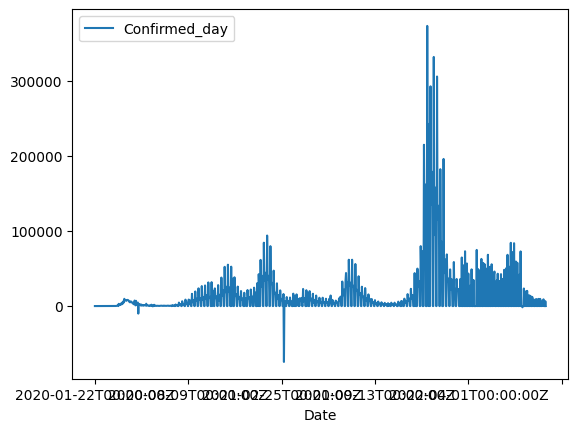

In [54]:
df_España.plot.line(x='Date', y='Confirmed_day')